In [27]:
import fitsio
import numpy as np
from scipy.spatial import KDTree
import os
import sys


sys.path.append("/home/vwetzell/gitrepos/highpm")
from highpm.gnomonic_converter import projectGnomonic

exposure_data = fitsio.read(
    "/home/vwetzell/Documents/Sculptor/y6a1.exposures.positions.fits.gz"
)

exposure_radec = np.vstack((exposure_data["ra"], exposure_data["dec"])).T

ra0 = 53.9254167
dec0 = -54.0491667

xi, eta, *_ = projectGnomonic(
    exposure_data["ra"],
    exposure_data["dec"],
    np.zeros_like(exposure_data["ra"]),
    np.zeros_like(exposure_data["ra"]),
    ra0,
    dec0,
)

good_pointings = np.where(np.isnan(xi) == False)
xi = xi[good_pointings]
eta = eta[good_pointings]

# import matplotlib.pyplot as plt

# plt.figure(figsize=(8, 8))
# plt.axis("equal")
# plt.scatter(xi, eta, s=1)
# plt.xlabel("xi [deg]")
# plt.ylabel("eta [deg]")
# plt.xlim(50, -50)
# plt.ylim(-50, 50)
# plt.show()

exposure_tree = KDTree(np.array(list(zip(xi, eta))))

RetII_idx = exposure_tree.query_ball_point([0, 0], r=5.0)

RetII_exposures = exposure_data[good_pointings][RetII_idx]

notY = np.arange(len(RetII_exposures))[(RetII_exposures["filter"] != "Y")]

# np.save("/home/vwetzell/Documents/RetII_expnum.npy", RetII_exposures[notY]["expnum"])

In [28]:
import healpy as hp

RetII_vec = hp.ang2vec(ra0, dec0, lonlat=True)

hp.query_disc(32, RetII_vec, radius=np.radians(5.0))


array([10791, 10792, 10898, 10899, 10900, 10901, 11001, 11002, 11003,
       11004, 11100, 11101, 11102, 11103, 11104, 11196, 11197, 11198,
       11199, 11288, 11289, 11290, 11376])

RA range: 12.487536066017086 to 15.64309181518908
DEC range: -35.68117978108526 to -32.62481232901697


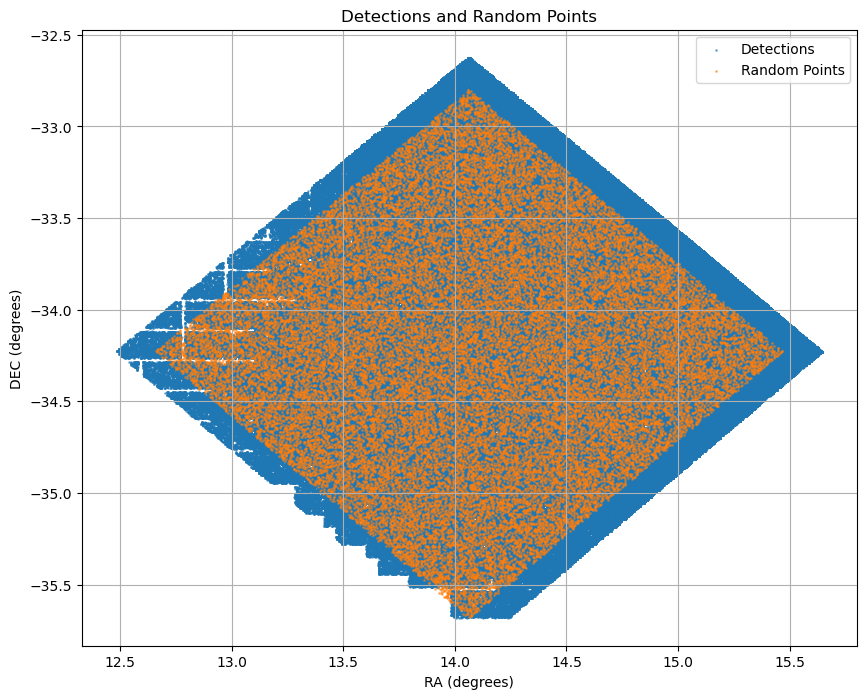

In [5]:
import fitsio
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp

data = fitsio.read(
    "/home/vwetzell/Documents/Sculptor/Sculptor_healpix_detections/cleaned_detections_hp09541.fits"
)

ra_min, ra_max = np.min(data["BEST_RA"]), np.max(data["BEST_RA"])
dec_min, dec_max = np.min(data["BEST_DEC"]), np.max(data["BEST_DEC"])

print(f"RA range: {ra_min} to {ra_max}")
print(f"DEC range: {dec_min} to {dec_max}")

rng = np.random.default_rng(42)

ra_rand = rng.uniform(ra_min, ra_max, size=100000)
dec_rand = rng.uniform(dec_min, dec_max, size=100000)

pixels = hp.ang2pix(
    32,
    np.radians(90 - dec_rand),
    np.radians(ra_rand),
)

plt.figure(figsize=(10, 8))
plt.scatter(data["BEST_RA"], data["BEST_DEC"], s=1, alpha=0.5, label="Detections")
plt.scatter(
    ra_rand[pixels == 9541],
    dec_rand[pixels == 9541],
    s=1,
    alpha=0.5,
    label="Random Points",
)
plt.xlabel("RA (degrees)")
plt.ylabel("DEC (degrees)")
plt.title("Detections and Random Points")
plt.legend()
plt.grid(True)
plt.show()

In [1]:
import fitsio
import numpy as np
import glob
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from astropy.coordinates import SkyCoord, match_coordinates_sky
import astropy.units as u
import numpy.lib.recfunctions as rfn

fl = glob.glob(
    "/home/vwetzell/Documents/Sculptor/Sculptor_updated_3hlr_modest*_movers.fits"
)
# fl.append(
#     glob.glob(
#         "/home/vwetzell/Documents/Sculptor/Sculptor_updated_3hlr_slow_movers.fits"
#     )[0]
# )
# fl.append(
#     glob.glob(
#         "/home/vwetzell/Documents/Sculptor/Sculptor_updated_1hlr_fast_movers.fits"
#     )[0]
# )


data_lsit = []
for f in fl:
    fits = fitsio.FITS(f, "r")
    temp_data = fits[1].read()
    data_lsit.append(temp_data)

data = np.concatenate(data_lsit)

data = data[data["color_err"] == 0.0]

# data = data[(np.abs(data["pmra"]) > 50) & (np.abs(data["pmdec"]) > 50)]

# data = data[((5 + data["dof"]) / 2) > 20]
data = data[(data["g_mag"] > 10) & (data["g_mag"] < 30)]



In [2]:
coadd_data = fitsio.FITS("/home/vwetzell/Documents/Sculptor/Sculptor_coadds.fits", "r")[
    1
].read(
    columns=[
        "ALPHAWIN_J2000",
        "DELTAWIN_J2000",
        "SPREAD_MODEL_I",
        "SPREADERR_MODEL_I",
    ]
)

coadd_coords = SkyCoord(
    ra=coadd_data["ALPHAWIN_J2000"] * u.deg,
    dec=coadd_data["DELTAWIN_J2000"] * u.deg,
)

decam_coords = SkyCoord(ra=data["ra"] * u.deg, dec=data["dec"] * u.deg)

idx_coadd, d2d_coadd, _ = match_coordinates_sky(
    decam_coords,
    coadd_coords,
    nthneighbor=1,
)

decam_coadd_matched = rfn.merge_arrays(
    [data, coadd_data[idx_coadd]],
    asrecarray=True,
    flatten=True,
)


In [3]:

def coadd_extended_class(spread_model,spread_model_error):
    """ DES DR2 extended classifier for stars and galaxies using coadd quantities.

        0 : High-confidence stars
        1 : Likely stars
        2 : Likely galaxies
        3 : High-confidence galaxies
       -9 : Failures

    Parameters
    ----------
    spread_model      : SExtractor spread model value in a band
    spread_model_error: SExtractor spread model error in a band
    
    Returns
    -------
    extended_class    : Extended classifier output
    """
    extend_val  = ((spread_model + 3.0*spread_model_error) > 0.005)*1
    extend_val += ((spread_model + 1.0*spread_model_error) > 0.003)*1
    extend_val += ((spread_model - 1.0*spread_model_error) > 0.002)*1

    extend_val[spread_model==-1]=-9
    extend_val[(spread_model==0) & (spread_model_error==0)]=-9
    extend_val[(spread_model==1) & (spread_model_error==1)]=-9
    return(extend_val)

extmash = coadd_extended_class(
    decam_coadd_matched["SPREAD_MODEL_I"],
    decam_coadd_matched["SPREADERR_MODEL_I"],
)

data = decam_coadd_matched[extmash == 0]  # Only high-confidence stars

In [4]:


gaia_file = "/home/vwetzell/Documents/Sculptor/Sculptor_gaia_3hlr.fits"

gaia_data = fitsio.FITS(gaia_file, "r")[1].read()

gaia_fields = gaia_data.dtype.names

dtype_gaia = [("gaia_" + field, gaia_data[field].dtype) for field in gaia_fields]

gaia_data = np.rec.fromarrays(
    [gaia_data[field] for field in gaia_fields],
    dtype=dtype_gaia,
)

gaia_sc = SkyCoord(ra=gaia_data["gaia_ra"] * u.deg, dec=gaia_data["gaia_dec"] * u.deg)

decam_sc = SkyCoord(ra=data["ra"] * u.deg, dec=data["dec"] * u.deg)

idx, d2d, _ = match_coordinates_sky(
    gaia_sc,
    decam_sc,
    nthneighbor=1,
)

idx = np.unique(idx[d2d < 1.0 * u.arcsec])

decam_matched = data[idx]

not_gaia_data = data[~np.isin(np.arange(len(data)), idx)]


# matched_decam_gaia = rfn.merge_arrays(
#     [gaia_data, decam_matched],
#     asrecarray=True,
#     flatten=True,
# )

# not_gaia_data = np.concatenate([not_gaia_data, decam_matched[d2d > 1.0 * u.arcsec]])

# not_gaia_data = np.unique(not_gaia_data)

# decam_matched = decam_matched[d2d < 1.0 * u.arcsec]

# decam_matched = np.unique(decam_matched)

# matched_decam_gaia = matched_decam_gaia[
#     np.hypot(matched_decam_gaia["gaia_pmra"], matched_decam_gaia["gaia_pmdec"]) < 10
# ]

print(len(data), len(decam_matched) + len(not_gaia_data))


51063 51063


/home/vwetzell/miniconda3/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


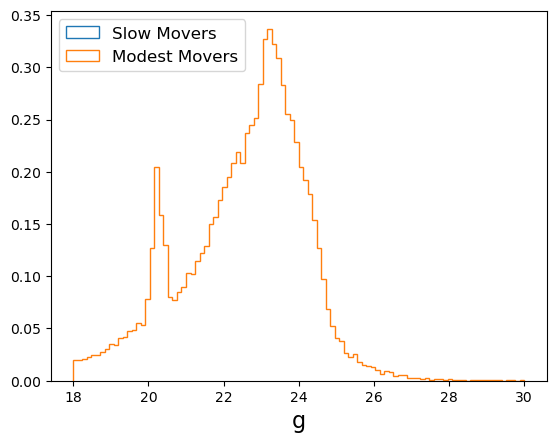

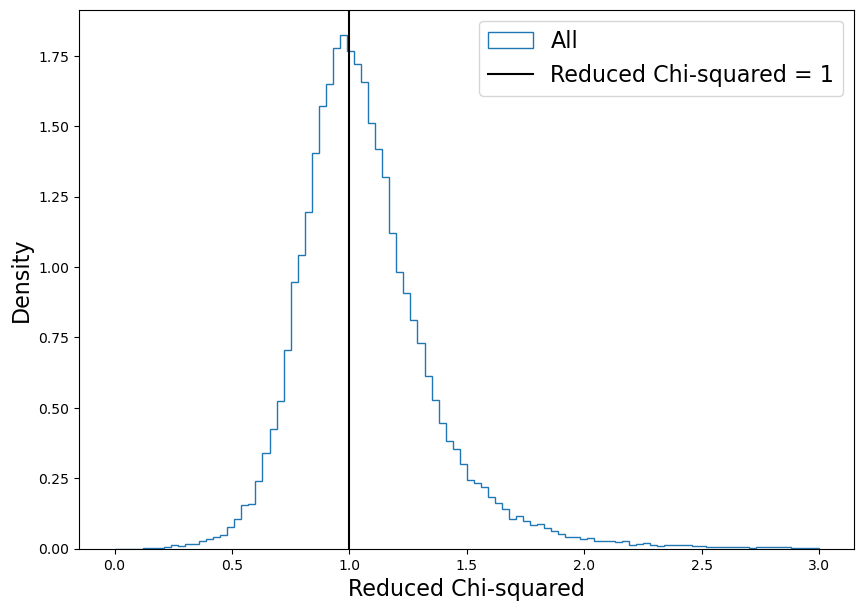

In [5]:


gaia_mag_lim = 22.5

plt.figure()
plt.hist(
    data["g_mag"][data["mtype"] == "slow"],
    bins=100,
    histtype="step",
    range=(18, 30),
    density=True,
    label="Slow Movers",
)
plt.hist(
    data[data["mtype"] == "modest1"]["g_mag"],
    bins=100,
    histtype="step",
    range=(18, 30),
    density=True,
    label="Modest Movers",
)
plt.xlabel("g", fontsize=16)
plt.legend(fontsize=12, loc=2)
plt.show()

plt.figure(figsize=(10, 7))
plt.hist(
    (data["chisqTotal"] / data["dof"]),
    bins=100,
    histtype="step",
    range=(0, 3),
    density=True,
    label="All",
)
# plt.hist(
#     (decam_matched["chisqTotal"] / decam_matched["dof"])[
#         decam_matched["mtype"] == "modest1"
#     ],
#     bins=100,
#     histtype="step",
#     range=(0, 3),
#     # density=True,
#     label="Gaia Modest Movers",
# )
# plt.hist(
#     (not_gaia_data["chisqTotal"] / not_gaia_data["dof"])[
#         not_gaia_data["mtype"] == "modest1"
#     ],
#     bins=100,
#     histtype="step",
#     range=(0, 3),
#     # density=True,
#     label="Not Gaia Modest Movers",
# )
# plt.hist(
#     data["chisqTotal"][(data["mtype"] == "slow") & (data["g_mag"] > 23)]
#     / data["dof"][(data["mtype"] == "slow") & (data["g_mag"] > 23)],
#     bins=100,
#     histtype="step",
#     range=(0, 3),
#     density=True,
#     label="Faint Slow Movers (g > 23)",
# )
# plt.hist(
#     data["chisqTotal"][(data["mtype"] == "slow") & (data["g_mag"] > 24)]
#     / data["dof"][(data["mtype"] == "slow") & (data["g_mag"] > 24)],
#     bins=100,
#     histtype="step",
#     range=(0, 3),
#     density=True,
#     label="Faint Slow Movers (g > 24)",
# )
# plt.hist(
#     data["chisqTotal"][(data["mtype"] == "modest1") & (data["g_mag"] > 23)]
#     / data["dof"][(data["mtype"] == "modest1") & (data["g_mag"] > 23)],
#     bins=100,
#     histtype="step",
#     range=(0, 3),
#     density=True,
#     label="Modest Movers (g > 23)",
# )
# plt.yscale("log")
plt.axvline(1.0, color="k",  label="Reduced Chi-squared = 1")
plt.xlabel("Reduced Chi-squared", fontsize=16)
plt.ylabel("Density", fontsize=16)
plt.legend(fontsize=16)
plt.show()

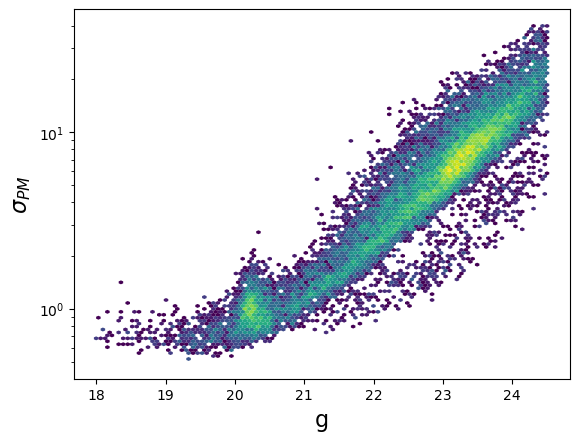

In [6]:
plt.figure()
plt.hexbin(
    data["g_mag"],
    1000*np.sqrt((data["c_vxvx"] + data["c_vyvy"])/2),
    gridsize=100,
    cmap="viridis",
    mincnt=5,
    edgecolors="none",
    linewidths=0,
    extent=(18, 24.5, np.log10(0.5), np.log10(40.)),
    norm=LogNorm(),
    yscale="log",
)
plt.xlabel("g", fontsize=16)
plt.ylabel(r"$\sigma_{PM}$", fontsize=16)
plt.show()

In [7]:
pmPlot = np.load("pm_plot.npz", allow_pickle=True)
imag = pmPlot["imag"]
med_dec = pmPlot["med_dec"]
med_lsst = pmPlot["med_lsst"]
dr5_G = pmPlot["dr5_G"]
Gi = pmPlot["Gi"]
dr5_sigpm = pmPlot["dr5_sigpm"]
dr3_sigpm = pmPlot["dr3_sigpm"]



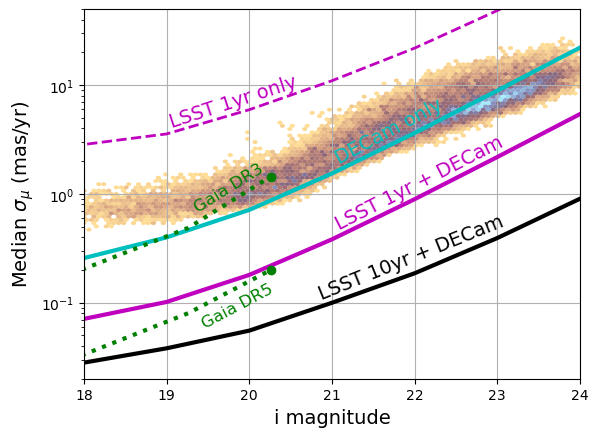

In [8]:
from matplotlib.ticker import ScalarFormatter

# Try plotting the medians among points
fontsize=14


# DECam only
plt.semilogy(imag, med_dec[:,0], 'c-', lw=3, label = 'DECam')
plt.text(21, med_dec[5,0]*1.15, 'DECam only', 
        color='c', fontsize=fontsize, rotation=28, ha='left',va='bottom')

# LSST Only
# plt.semilogy(imag, med_lsst[:,5], 'm--', lw=2, label = 'LSST 5yr')
# plt.text(16.5, med_lsst[0,5]*1.05, 'LSST 5yr only',
#         color='m', fontsize=fontsize, rotation=3, ha='left',va='bottom')
plt.semilogy(imag, med_lsst[:,1], 'm--', lw=2, label = 'LSST 1yr')
plt.text(19, med_lsst[0,1]*1.55, 'LSST 1yr only', 
        color='m', fontsize=fontsize, rotation=18, ha='left',va='bottom')

# LSST + DECam
plt.semilogy(imag, med_dec[:,1], 'm-', lw=3, label = 'LSST 1yr + DECam')
plt.text(21, med_dec[5,1]*1.15, 'LSST 1yr + DECam', 
        color='m', fontsize=fontsize, rotation=27, ha='left',va='bottom')

plt.semilogy(imag, med_dec[:,10], 'k-', lw=3, label = 'LSST 10yr + DECam')
plt.text(20.8, med_dec[5,10]*1.0, 'LSST 10yr + DECam', 
        color='k', fontsize=fontsize, rotation=22, ha='left',va='bottom')


# Plot Gaia
plt.semilogy(dr5_G - Gi, dr5_sigpm, 'g:', lw=3, label='Gaia DR5')
plt.semilogy((dr5_G-Gi)[-1],dr5_sigpm[-1], 'go')
plt.text(19.4, 0.055, 'Gaia DR5', 
        color='g', fontsize=12, rotation=28, ha='left',va='bottom')

plt.semilogy(dr5_G - Gi, dr3_sigpm, 'g:', lw=3, label='Gaia DR3')
plt.semilogy((dr5_G-Gi)[-1],dr3_sigpm[-1], 'go')
plt.text(19.3, 0.65, 'Gaia DR3', 
        color='g', fontsize=12, rotation=32, ha='left',va='bottom')

# Put numbers on y axis
plt.gca().yaxis.set_major_formatter(ScalarFormatter())

quality = ((data["dof"] - 5) / 2) > 10
quality &= (data["chisqTotal"] / data["dof"]) < 1.5
quality &= (data["chisqTotal"] / data["dof"]) > 0.5

plt.hexbin(
    data["i_mag"][quality],
    1000 * np.sqrt((data["c_vxvx"] + data["c_vyvy"]) / 2)[quality],
    gridsize=100,
    cmap="managua",
    mincnt=5,
    edgecolors="none",
    linewidths=0,
    extent=(18, 24, np.log10(0.02), np.log10(50.0)),
    #     norm=LogNorm(),
    yscale="log",
    zorder=0,
    alpha=0.7,
)

plt.xlim(18,24)
plt.ylim(0.02,50)
# plt.legend(loc=2)
plt.xlabel('i magnitude', fontsize=fontsize)
plt.ylabel(r'Median $\sigma_\mu$ (mas/yr)', fontsize=fontsize)
plt.grid()
# plt.arrow(19,med_lsst[1,2],0,med_dec[1,1]-med_lsst[1,2],
# plt.arrow(19,med_lsst[3,1],0,med_dec[3,1]-med_lsst[3,1],
#          width=0.3,
#          length_includes_head=True,
#          head_length=0.04,
#          head_width=0.6,
#          alpha=0.3,color='m')

# plt.arrow(21,med_lsst[3,2],0,med_dec[3,1]-med_lsst[3,2],
# plt.arrow(21,med_lsst[5,1],0,med_dec[5,1]-med_lsst[5,1],
#          width=0.3,
#          length_includes_head=True,
#          head_length=0.2,
#          head_width=0.6,
#          alpha=0.3,color='m')

# plt.arrow(23,med_lsst[5,2],0,med_dec[5,1]-med_lsst[5,2],
# plt.arrow(23,med_lsst[7,1],0,med_dec[7,1]-med_lsst[7,1],
#          width=0.3,
#          length_includes_head=True,
#          head_length=1,
#          head_width=0.6,
#          alpha=0.3,color='m')
plt.savefig('pm_vs_mag.pdf')

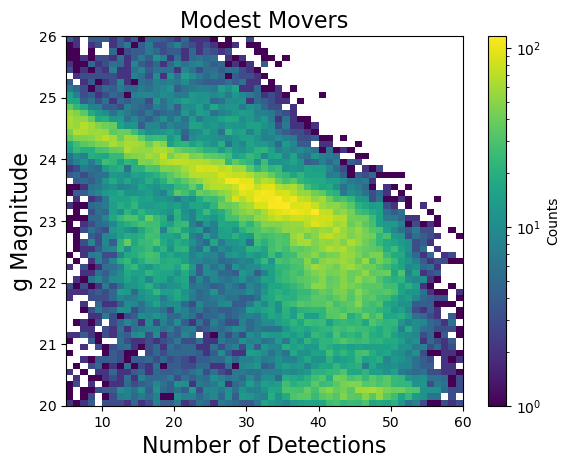

/home/vwetzell/miniconda3/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


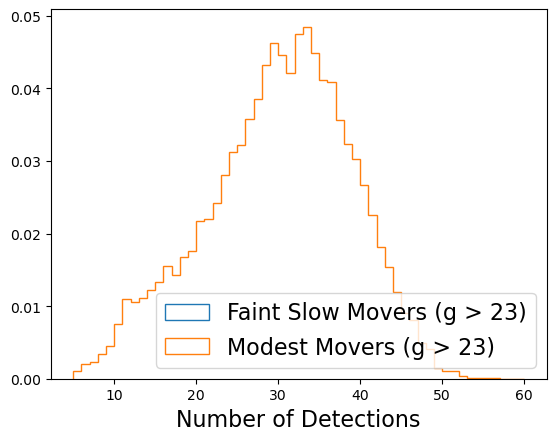

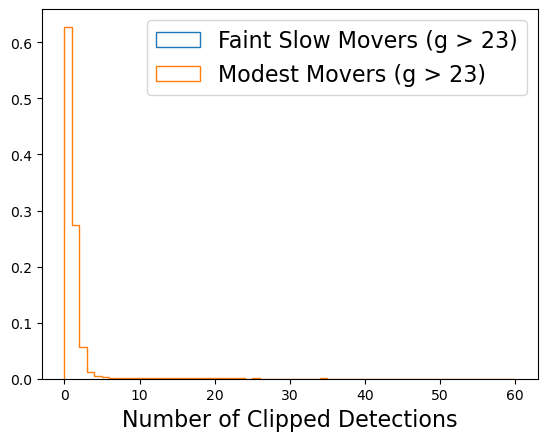

In [9]:
# plt.figure()
# plt.hist2d(
#     ((data["dof"] + 5) / 2)[(data["mtype"] == "slow")],
#     data["g_mag"][(data["mtype"] == "slow")],
#     bins=(55, 60),
#     norm=LogNorm(),
#     range=((5, 60), (20, 26)),
# )
# plt.colorbar(label="Counts")
# plt.xlabel("Number of Detections", fontsize=16)
# plt.ylabel("g Magnitude", fontsize=16)
# plt.title("Slow Movers", fontsize=16)
# plt.show()

plt.figure()
plt.hist2d(
    ((data["dof"] + 5) / 2)[(data["mtype"] == "modest1")],
    data["g_mag"][(data["mtype"] == "modest1")],
    bins=(55, 60),
    norm=LogNorm(),
    range=((5, 60), (20, 26)),
)
plt.colorbar(label="Counts")
plt.xlabel("Number of Detections", fontsize=16)
plt.ylabel("g Magnitude", fontsize=16)
plt.title("Modest Movers", fontsize=16)
plt.show()


plt.figure()
plt.hist(
    ((data["dof"] + 5) / 2)[
        (data["mtype"] == "slow") & (data["g_mag"] > 23) & (data["g_mag"] < 24)
    ],
    bins=55,
    histtype="step",
    range=(5, 60),
    density=True,
    label="Faint Slow Movers (g > 23)",
)
plt.hist(
    ((data["dof"] + 5) / 2)[
        (data["mtype"] == "modest1") & (data["g_mag"] > 23) & (data["g_mag"] < 24)
    ],
    bins=55,
    histtype="step",
    range=(5, 60),
    density=True,
    label="Modest Movers (g > 23)",
)
plt.xlabel("Number of Detections", fontsize=16)
plt.legend(fontsize=16)
# plt.yscale("log")
plt.show()

plt.figure()
plt.hist(
    (data["nClip"])[
        (data["mtype"] == "slow") & (data["g_mag"] > 23) & (data["g_mag"] < 24)
    ],
    bins=60,
    histtype="step",
    range=(0, 60),
    density=True,
    label="Faint Slow Movers (g > 23)",
)
plt.hist(
    (data["nClip"])[
        (data["mtype"] == "modest1") & (data["g_mag"] > 23) & (data["g_mag"] < 24)
    ],
    bins=60,
    histtype="step",
    range=(0, 60),
    density=True,
    label="Modest Movers (g > 23)",
)
# plt.yscale("log")
plt.xlabel("Number of Clipped Detections", fontsize=16)
plt.legend(fontsize=16)
plt.show()

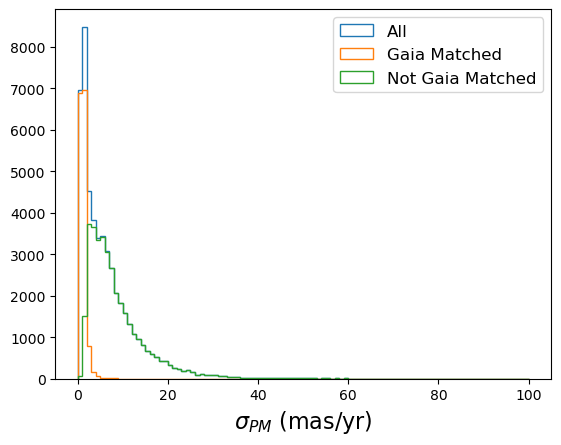

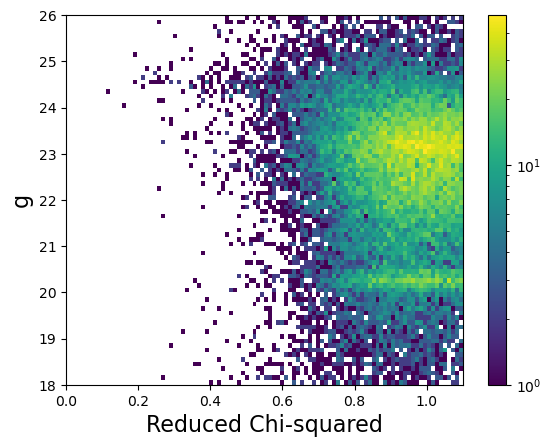

In [10]:
# plt.figure()
# plt.hist(
#     (1e-3) * data["pm"] / np.sqrt((data["c_vxvx"] + data["c_vyvy"]) / 2),
#     bins=100,
#     histtype="step",
#     range=(0, 10),
#     density=True,
# )
# plt.hist(
#     (1e-3)
#     * (data["pm"] / np.sqrt((data["c_vxvx"] + data["c_vyvy"]) / 2))[
#         data["mtype"] == "slow"
#     ],
#     bins=100,
#     histtype="step",
#     range=(0, 10),
#     density=True,
# )
# plt.hist(
#     (1e-3)
#     * (data["pm"] / np.sqrt((data["c_vxvx"] + data["c_vyvy"]) / 2))[
#         (data["mtype"] == "slow") & (data["g_mag"] > 23)
#     ],
#     bins=100,
#     histtype="step",
#     range=(0, 10),
#     density=True,
# )
# plt.hist(
#     (1e-3)
#     * (data["pm"] / np.sqrt((data["c_vxvx"] + data["c_vyvy"]) / 2))[
#         data["mtype"] == "modest1"
#     ],
#     bins=100,
#     histtype="step",
#     range=(0, 10),
#     density=True,
# )
# # plt.yscale("log")
# plt.show()

plt.figure()
plt.hist(
    1000*np.sqrt((data["c_vxvx"] + data["c_vyvy"]) / 2),
    bins=100,
    histtype="step",
    range=(0, 100),
    # density=True,
    label="All",
)
plt.hist(
    1000*np.sqrt((decam_matched["c_vxvx"] + decam_matched["c_vyvy"]) / 2),
    bins=100,
    histtype="step",
    range=(0, 100),
    # density=True,
    label="Gaia Matched",
)
plt.hist(
    1000*np.sqrt((not_gaia_data["c_vxvx"] + not_gaia_data["c_vyvy"]) / 2),
    bins=100,
    histtype="step",
    range=(0, 100),
    # density=True,
    label="Not Gaia Matched",
)
# plt.hist(
#     np.sqrt((data["c_vxvx"] + data["c_vyvy"]) / 2)[
#         (data["mtype"] == "slow") & (data["g_mag"] > 23)
#     ],
#     bins=100,
#     histtype="step",
#     range=(0, 0.1),
#     density=True,
#     label="Slow Movers (g > 23)",
# )
# plt.hist(
#     np.sqrt((data["c_vxvx"] + data["c_vyvy"]) / 2)[
#         (data["mtype"] == "modest1") & (data["g_mag"] > 23)
#     ],
#     bins=100,
#     histtype="step",
#     range=(0, 0.1),
#     density=True,
#     label="Modest Movers (g > 23)",
# )
plt.xlabel(r"$\sigma_{PM}$ (mas/yr)", fontsize=16)
plt.legend(fontsize=12, loc=1)
# plt.yscale("log")
plt.show()

# plt.figure()
# plt.hist(
#     np.sqrt((data["c_xx"] + data["c_yy"]) / 2),
#     bins=100,
#     histtype="step",
#     range=(0, 0.1),
#     density=True,
# )
# plt.hist(
#     np.sqrt((data["c_xx"] + data["c_yy"]) / 2)[data["mtype"] == "slow"],
#     bins=100,
#     histtype="step",
#     range=(0, 0.1),
#     density=True,
# )
# plt.hist(
#     np.sqrt((data["c_xx"] + data["c_yy"]) / 2)[
#         (data["mtype"] == "slow") & (data["g_mag"] > 23)
#     ],
#     bins=100,
#     histtype="step",
#     range=(0, 0.1),
#     density=True,
# )
# plt.hist(
#     np.sqrt((data["c_xx"] + data["c_yy"]) / 2)[data["mtype"] == "modest1"],
#     bins=100,
#     histtype="step",
#     range=(0, 0.1),
#     density=True,
# )
# # plt.yscale("log")
# plt.show()

plt.figure()
plt.hist2d(
    data["chisqTotal"] / data["dof"],
    data["g_mag"],
    bins=(100, 80),
    range=[[0, 1.1], [18, 26]],
    norm=LogNorm(),
)
plt.colorbar()
plt.xlabel("Reduced Chi-squared", fontsize=16)
plt.ylabel("g", fontsize=16)
plt.show()

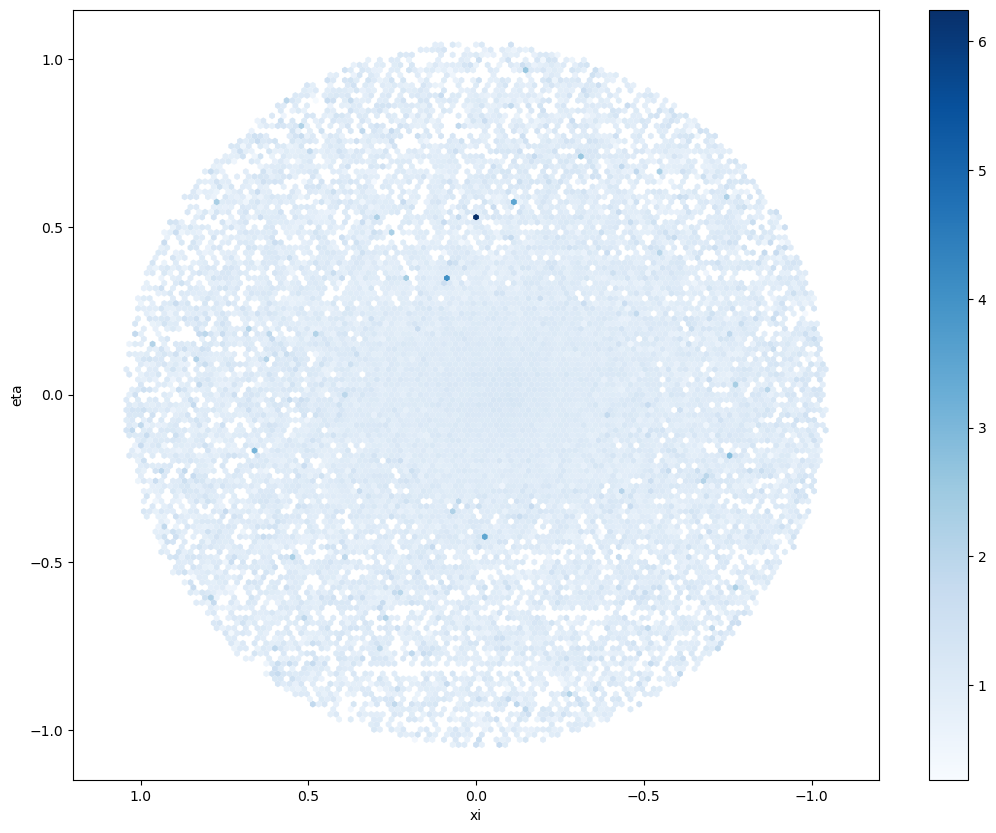

In [11]:

plt.figure(figsize=(13, 10))
plt.gca().invert_xaxis()
plt.axis("equal")
plt.hexbin(
    data["xi"],
    data["eta"],
    C=data["chisqTotal"] / data["dof"],
    edgecolors="none",
    reduce_C_function=np.median,
    linewidths=0,
    gridsize=120,
    mincnt=1,
    # norm=LogNorm(),
    cmap="Blues",
)
plt.colorbar()
plt.xlabel("xi")
plt.ylabel("eta")
plt.show()

In [12]:
# plt.figure(figsize=(13, 10))
# plt.axis("equal")
# plt.hexbin(
#     data["pmra"][data["mtype"] == "slow"],
#     data["pmdec"][data["mtype"] == "slow"],
#     gridsize=100,
#     cmap="viridis",
#     # norm=LogNorm(),
#     mincnt=1,
#     linewidths=0.0,
#     extent=(-100, 100, -100, 100),
# )
# plt.xlabel("PMRA (mas/yr)", fontsize=16)
# plt.ylabel("PMDEC (mas/yr)", fontsize=16)
# plt.colorbar()
# plt.show()

# data = data[((data["dof"] + 5) / 2) > 10]

# data = data[(data["g_mag"] < 23) & (data["g_mag"] > 15)]

# output_file = "/home/vwetzell/Documents/Sculptor/Sculptor_PM_3hlr_140725.fits"
# fitsio.write(output_file, data, extname="Sculptor", clobber=True)
# print(f"Data saved to {output_file}")

# data = data[data["pm"] > 10]

# plt.figure()
# plt.hist(
#     data["g_i_mag"][data["g_i_mag_err"] == 0.0],
#     bins=500,
#     range=(-10.0, 10.0),
#     histtype="step",
#     density=True,
# )
# plt.hist(
#     data["g_i_mag"][(data["g_i_mag_err"] != 0.0) & (data["g_i_mag"] != 0.0)],
#     bins=500,
#     range=(-10.0, 10.0),
#     histtype="step",
#     density=True,
# )
# plt.show()

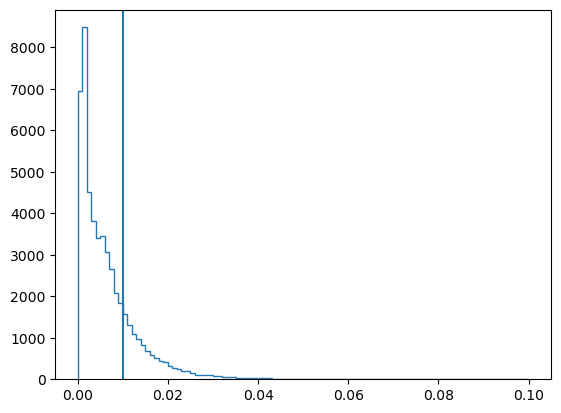

In [13]:
plt.figure()
plt.hist(
    np.sqrt((data["c_vxvx"] + data["c_vyvy"]) / 2),
    bins=100,
    histtype="step",
    range=(0, 0.1),
)
plt.axvline(0.01)
plt.show()

2522 matched spectra


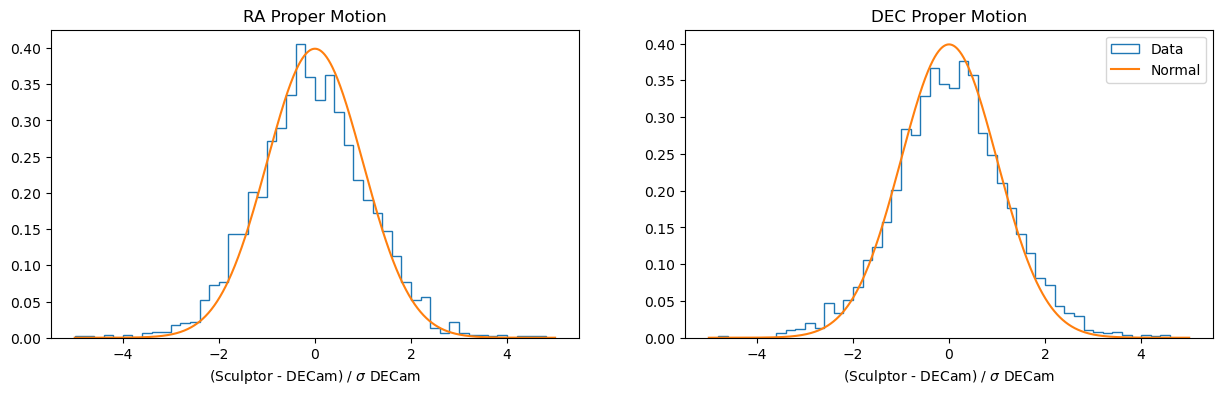

In [14]:
from astropy.coordinates import SkyCoord, match_coordinates_sky
import astropy.units as u
import numpy.lib.recfunctions as rfn

pmra0 = 0.081
pmdec0 = -0.136

spectra_data = fitsio.FITS(
    "/home/vwetzell/Downloads/combined_structure_sculptor_v9d1.fits", "r"
)[1].read(columns=["ra", "dec", "member_final"])

spectra_data = spectra_data[spectra_data["member_final"] == 1]

spectra_coords = SkyCoord(
    ra=spectra_data["ra"] * u.deg,
    dec=spectra_data["dec"] * u.deg,
)

spectra_fields = ["ra", "dec", "member_final"]

dtype_spectra = [
    ("spectra_" + name, spectra_data[name].dtype) for name in spectra_fields
]

# spectra_data = rfn.unstructured_to_structured(spectra_data, dtype=dtype_spectra)
spectra_data = np.rec.fromarrays(
    [spectra_data[field] for field in spectra_fields],
    dtype=dtype_spectra,
)

decam_coords = SkyCoord(
    ra=data["ra"] * u.deg,
    dec=data["dec"] * u.deg,
)

idx, d2d, d3d = match_coordinates_sky(spectra_coords, decam_coords, nthneighbor=1)

matched_decam_spectra = rfn.merge_arrays(
    [data[idx], spectra_data],
    flatten=True,
    usemask=True,
)

matched_decam_spectra = matched_decam_spectra[d2d < 0.5 * u.arcsec]

print(len(matched_decam_spectra), "matched spectra")


def gaussian(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))


x = np.linspace(-5, 5, 1000)
y = gaussian(x, 0, 1)

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].hist(
    (pmra0 - matched_decam_spectra["pmra"])
    / (np.sqrt(matched_decam_spectra["c_vxvx"]) * 1000),
    bins=50,
    histtype="step",
    range=(-5, 5),
    density=True,
    label="Data",
)
ax[0].plot(x, y, label="Normal")
ax[0].set_xlabel(r"(Sculptor - DECam) / $\sigma$ DECam")
ax[0].set_title("RA Proper Motion")

ax[1].hist(
    (pmdec0 - matched_decam_spectra["pmdec"])
    / (np.sqrt(matched_decam_spectra["c_vyvy"]) * 1000),
    bins=50,
    histtype="step",
    range=(-5, 5),
    density=True,
    label="Data",
)
ax[1].plot(x, y, label="Normal")
ax[1].set_xlabel(r"(Sculptor - DECam) / $\sigma$ DECam")
ax[1].legend()
ax[1].set_title("DEC Proper Motion")

plt.show()

9312 matched gaia


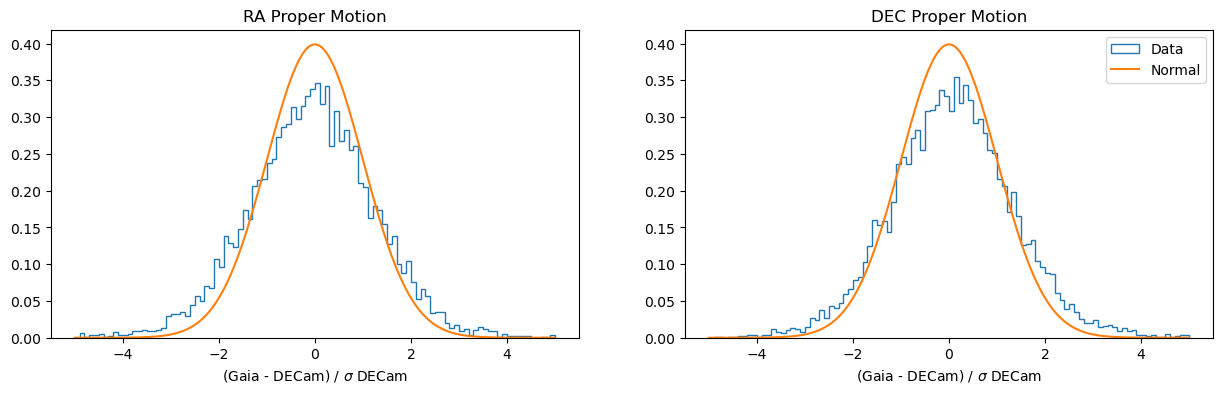

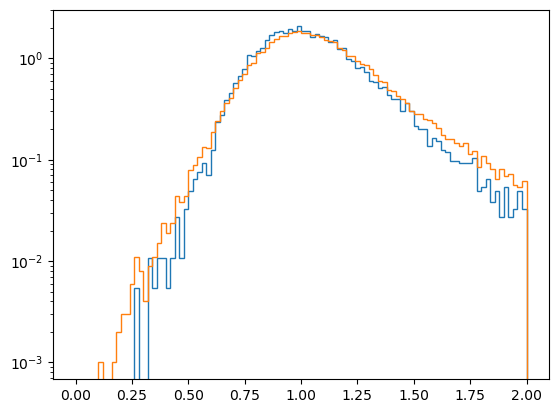

In [15]:
from astropy.coordinates import SkyCoord, match_coordinates_sky
import astropy.units as u
import numpy.lib.recfunctions as rfn

gaia_file = "/home/vwetzell/Documents/Sculptor/Sculptor_gaia_3hlr.fits"

gaia_data = fitsio.FITS(gaia_file, "r")[1].read()

gaia_fields = gaia_data.dtype.names

dtype_gaia = [("gaia_" + field, gaia_data[field].dtype) for field in gaia_fields]

gaia_data = np.rec.fromarrays(
    [gaia_data[field] for field in gaia_fields],
    dtype=dtype_gaia,
)

gaia_sc = SkyCoord(ra=gaia_data["gaia_ra"] * u.deg, dec=gaia_data["gaia_dec"] * u.deg)

decam_sc = SkyCoord(ra=data["ra"] * u.deg, dec=data["dec"] * u.deg)

idx, d2d, _ = match_coordinates_sky(gaia_sc, decam_sc, nthneighbor=1)

decam_matched = data[idx]

matched_decam_gaia = rfn.merge_arrays(
    [gaia_data, decam_matched],
    asrecarray=True,
    flatten=True,
)

matched_decam_gaia = matched_decam_gaia[d2d < 0.5 * u.arcsec]

matched_decam_gaia = matched_decam_gaia[
    np.hypot(matched_decam_gaia["gaia_pmra"], matched_decam_gaia["gaia_pmdec"]) < 10
]

print(len(matched_decam_gaia), "matched gaia")


def gaussian(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))


x = np.linspace(-5, 5, 1000)
y = gaussian(x, 0, 1)

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].hist(
    (matched_decam_gaia["gaia_pmra"] - matched_decam_gaia["pmra"])
    / (np.sqrt(matched_decam_gaia["c_vxvx"]) * 1000),
    bins=100,
    histtype="step",
    range=(-5, 5),
    density=True,
    label="Data",
)
ax[0].plot(x, y, label="Normal")
ax[0].set_xlabel(r"(Gaia - DECam) / $\sigma$ DECam")
ax[0].set_title("RA Proper Motion")

ax[1].hist(
    (matched_decam_gaia["gaia_pmdec"] - matched_decam_gaia["pmdec"])
    / (np.sqrt(matched_decam_gaia["c_vyvy"]) * 1000),
    bins=100,
    histtype="step",
    range=(-5, 5),
    density=True,
    label="Data",
)
ax[1].plot(x, y, label="Normal")
ax[1].set_xlabel(r"(Gaia - DECam) / $\sigma$ DECam")
ax[1].legend()
ax[1].set_title("DEC Proper Motion")

plt.show()

plt.figure()
plt.hist(
    matched_decam_gaia["chisqTotal"] / matched_decam_gaia["dof"],
    bins=100,
    histtype="step",
    range=(0, 2),
    density=True,
)

plt.hist(
    data["chisqTotal"] / data["dof"],
    bins=100,
    histtype="step",
    range=(0, 2),
    density=True,
)
# plt.hist(
#     data["chisqTotal"][data["g_mag"] < gaia_mag_lim]
#     / data["dof"][data["g_mag"] < gaia_mag_lim],
#     bins=100,
#     histtype="step",
#     range=(0, 2),
#     density=True,
# )
# plt.hist(
#     data["chisqTotal"][data["g_mag"] > gaia_mag_lim]
#     / data["dof"][data["g_mag"] > gaia_mag_lim],
#     bins=100,
#     histtype="step",
#     range=(0, 2),
#     density=True,
# )
plt.yscale("log")
plt.show()

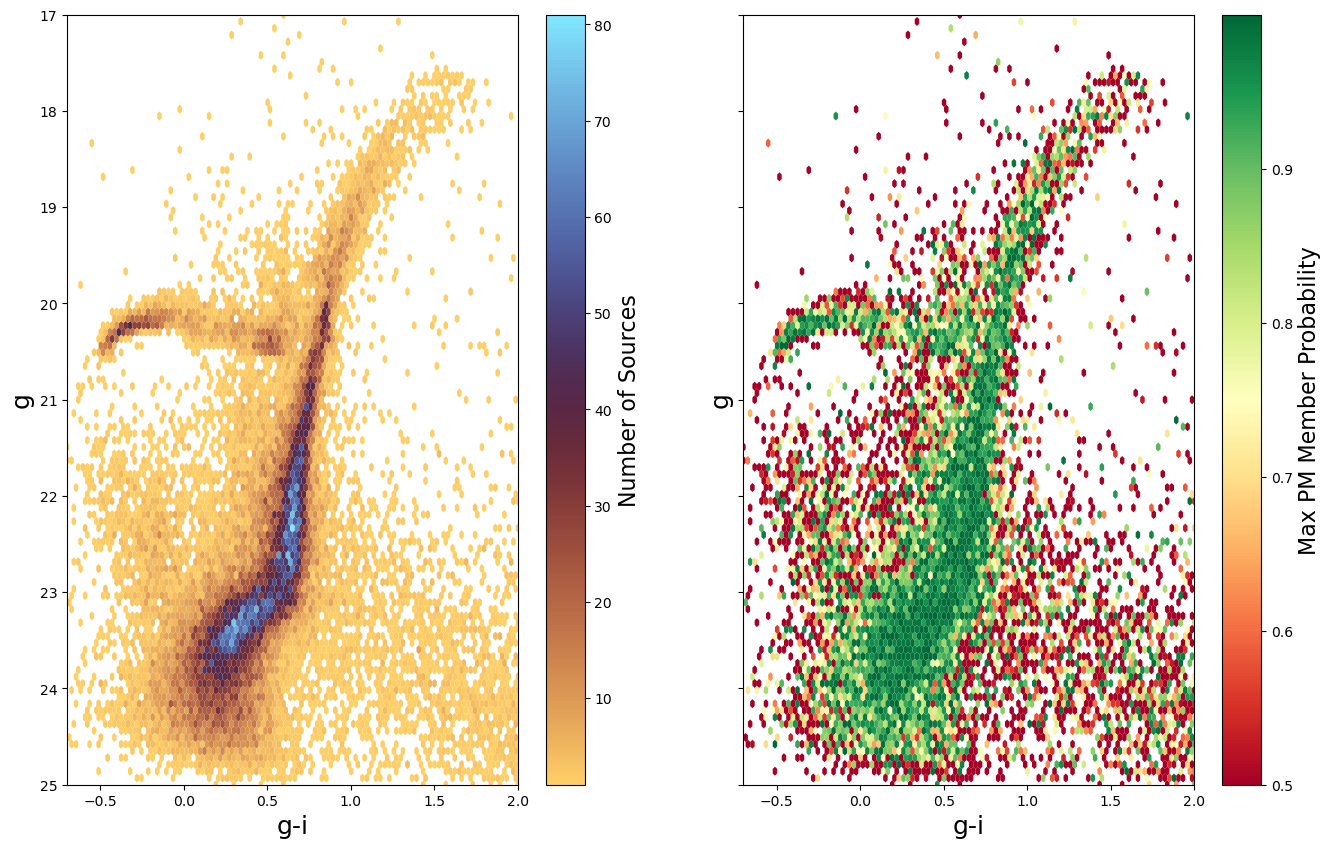

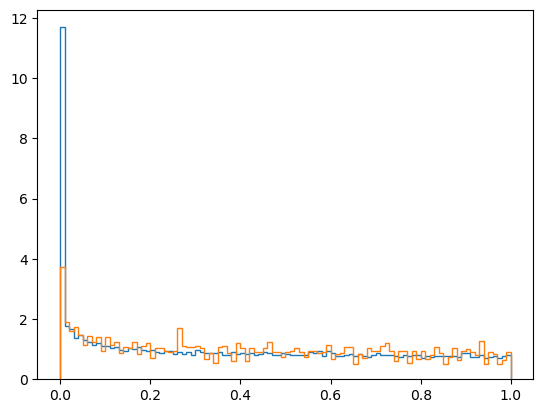

In [16]:
pmra0 = 0.081
pmdec0 = -0.136

# data = data[data["color_err"] == 0.0]
# data = data[data["g_mag"] != 0.0]

data = data[np.hypot(data["pmra"], data["pmdec"]) < 100.0]

data = data[(data["color"] > -0.7) & (data["color"] < 2.0)]
data = data[(data["g_mag"] > 17.0) & (data["g_mag"] < 25)]


pmCov = (
    np.array(
        [[data["c_vxvx"], data["c_vxvy"]], [data["c_vxvy"], data["c_vyvy"]]],
    ).T
    * 1000**2
)

pmCovMatched = (
    np.array(
        [
            [matched_decam_spectra["c_vxvx"], matched_decam_spectra["c_vxvy"]],
            [matched_decam_spectra["c_vxvy"], matched_decam_spectra["c_vyvy"]],
        ],
    ).T
    * 1000**2
)


def pmMemeberProb(pmra, pmdec, cov, pmra0, pmdec0):
    delta = np.stack([pmra0 - pmra, pmdec0 - pmdec], axis=1)
    cov_inv = np.linalg.inv(cov)
    det_cov = np.linalg.det(cov)
    d2 = np.einsum('ni,nij,nj->n', delta, cov_inv, delta)
    norm = 1.0 #/ (2 * np.pi * np.sqrt(det_cov))
    return norm * np.exp(-0.5 * d2)


pmProb = pmMemeberProb(
    data["pmra"],
    data["pmdec"],
    pmCov,
    pmra0,
    pmdec0,
)

data = data[pmProb > 0.01]

fig, ax = plt.subplots(1, 2, figsize=(16, 10), sharex=True, sharey=True)
hex1 = ax[0].hexbin(
    data["color"],
    data["g_mag"],
    gridsize=100,
    extent=(-0.7, 2, 17, 25),
    cmap="managua",
    edgecolors="none",
    linewidths=0,
    # norm=LogNorm(),
    mincnt=1,
)
fig.colorbar(
    hex1,
    ax=ax[0],
    orientation="vertical",
    # fraction=0.046,
    # pad=0.04,
).set_label("Number of Sources", fontsize=16)
# ax[0].invert_yaxis()
ax[0].set_xlabel("g-i", fontsize=18)
ax[0].set_ylabel("g", fontsize=18)
# ax[0].set_title("Not Weighted", fontsize=22)

from functools import partial

percentile = partial(np.percentile, q=100)

hex2 = ax[1].hexbin(
    data["color"],
    data["g_mag"],
    gridsize=100,
    extent=(-0.7, 2, 17, 25),
    cmap="RdYlGn",
    edgecolors="none",
    linewidths=0,
    # norm=LogNorm(),
    C=pmProb,
    reduce_C_function=percentile,
    # mincnt=3,
    vmin=0.5,
)

# hex2 = ax[1].scatter(
#     matched_decam_spectra["color"],
#     matched_decam_spectra["g_mag"],
#     s=5,
#     # color="deepskyblue",
#     c=pmMemeberProb(
#         matched_decam_spectra["pmra"],
#         matched_decam_spectra["pmdec"],
#         pmCovMatched,
#         pmra0,
#         pmdec0,
#     ),
#     alpha=1.0,
#     label="Spectroscopic Members",
#     cmap="cividis_r"
# )


fig.colorbar(
    hex2,
    ax=ax[1],
    orientation="vertical",
    # fraction=0.046,
    # pad=0.04,
).set_label("Max PM Member Probability", fontsize=16)
ax[1].set_xlim(-0.7, 2)
ax[1].set_ylim(17, 25)
ax[1].invert_yaxis()
ax[1].set_xlabel("g-i", fontsize=18)
ax[1].set_ylabel("g", fontsize=18)
# ax[1].set_title("PM Weighted", fontsize=22)
# ax[1].legend(fontsize=16)
plt.show()


plt.figure()
plt.hist(
    pmProb,
    bins=100,
    histtype="step",
    range=(0, 1),
    density=True,
)
plt.hist(
    pmMemeberProb(
        matched_decam_spectra["pmra"],
        matched_decam_spectra["pmdec"],
        pmCovMatched,
        pmra0,
        pmdec0,
    ),
    bins=100,
    histtype="step",
    range=(0, 1),
    density=True,
)
plt.show()

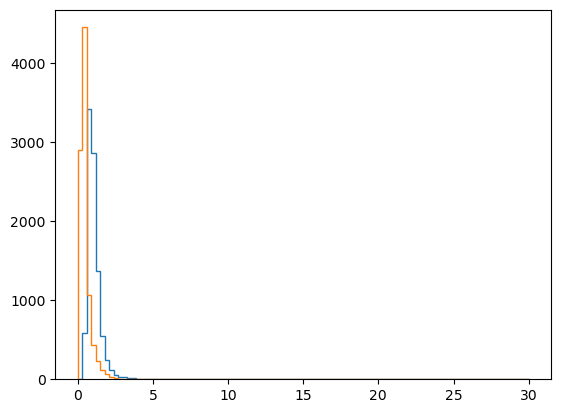

In [17]:
plt.figure()
plt.hist(
    np.sqrt(matched_decam_gaia["c_vxvx"]) * 1000,
    bins=100,
    histtype="step",
    range=(0, 30),
)
plt.hist(
    matched_decam_gaia["gaia_pmra_error"],
    bins=100,
    histtype="step",
    range=(0, 30),
)
plt.show()

Processing file: /home/vwetzell/Documents/Sculptor/Sculptor_new_updated/updated_skim_gpr_coadd_00693031.fits, EXPNUM: 693031
Processing file: /home/vwetzell/Documents/Sculptor/Sculptor_new_updated/updated_skim_gpr_coadd_00699966.fits, EXPNUM: 699966
Processing file: /home/vwetzell/Documents/Sculptor/Sculptor_new_updated/updated_skim_gpr_coadd_00390871.fits, EXPNUM: 390871
Processing file: /home/vwetzell/Documents/Sculptor/Sculptor_new_updated/updated_skim_gpr_coadd_00454657.fits, EXPNUM: 454657
Processing file: /home/vwetzell/Documents/Sculptor/Sculptor_new_updated/updated_skim_gpr_coadd_00699207.fits, EXPNUM: 699207
Processing file: /home/vwetzell/Documents/Sculptor/Sculptor_new_updated/updated_skim_gpr_coadd_00402234.fits, EXPNUM: 402234
Processing file: /home/vwetzell/Documents/Sculptor/Sculptor_new_updated/updated_skim_gpr_coadd_00466826.fits, EXPNUM: 466826
Processing file: /home/vwetzell/Documents/Sculptor/Sculptor_new_updated/updated_skim_gpr_coadd_00454663.fits, EXPNUM: 454663


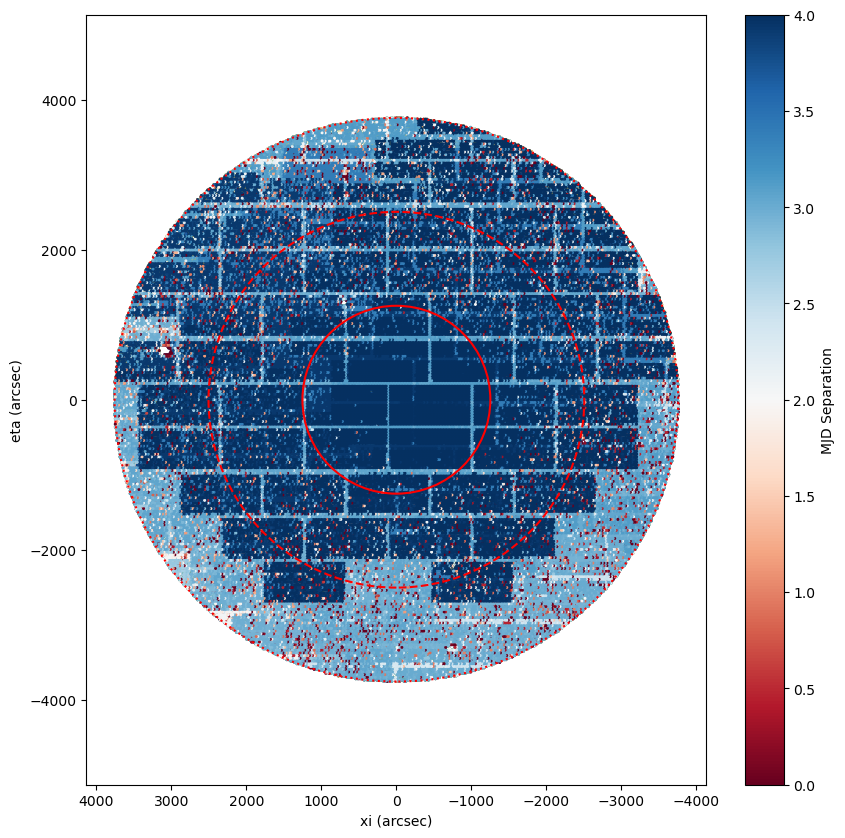

Data saved to /home/vwetzell/Documents/Sculptor/Sculptor_updated_3hlr.fits


In [1]:
import fitsio
import glob
import numpy as np
import numpy.lib.recfunctions as rfn
import os

fl = glob.glob("/home/vwetzell/Documents/Sculptor/Sculptor_new_updated/*.fits")

dataList = []

for f in fl:
    data = fitsio.read(f, ext=1)
    expnum = int(os.path.basename(f).split(".")[0][-8:])
    print(f"Processing file: {f}, EXPNUM: {expnum}")
    data = rfn.append_fields(
        data,
        "EXPNUM",
        len(data) * [expnum],
        dtypes=[("i8", ())],
        asrecarray=True,
    )
    dataList.append(data)

data = np.concatenate(dataList)

data = data[(data["NEW_RA_ERR"] > 0.0) & (data["NEW_DEC_ERR"] > 0.0)]


def projectGnomonic(ra, dec, delta_ra, delta_dec, ra0, dec0):
    deg2rad = np.pi / 180.0

    # Convert reference point and coordinates to radians
    ra0_rad = ra0 * deg2rad
    dec0_rad = dec0 * deg2rad
    ra_rad = np.asarray(ra) * deg2rad
    dec_rad = np.asarray(dec) * deg2rad

    # Convert direction vectors to radians
    delta_ra_rad = np.asarray(delta_ra) * deg2rad
    delta_dec_rad = np.asarray(delta_dec) * deg2rad

    # Angular differences
    dra = ra_rad - ra0_rad

    # Trigonometric terms
    sin_dra = np.sin(dra)
    cos_dra = np.cos(dra)
    sin_d0 = np.sin(dec0_rad)
    cos_d0 = np.cos(dec0_rad)
    sin_d = np.sin(dec_rad)
    cos_d = np.cos(dec_rad)

    # Denominator D
    D = sin_d0 * sin_d + cos_d0 * cos_d * cos_dra
    valid = D > 0

    # Initialize outputs with NaNs
    x = np.full_like(ra, np.nan)
    y = np.full_like(ra, np.nan)
    dx_proj = np.full_like(ra, np.nan)
    dy_proj = np.full_like(ra, np.nan)

    if not np.any(valid):
        return x, y, dx_proj, dy_proj

    # Compute x, y for valid points
    num_x = cos_d[valid] * sin_dra[valid]
    num_y = cos_d0 * sin_d[valid] - sin_d0 * cos_d[valid] * cos_dra[valid]
    D_valid = D[valid]
    x_valid = num_x / D_valid
    y_valid = num_y / D_valid

    # Partial derivatives (Jacobian components)
    term1 = sin_d0 * cos_d[valid] - cos_d0 * sin_d[valid] * cos_dra[valid]
    term2 = cos_d0 * cos_d[valid] + sin_d0 * sin_d[valid] * cos_dra[valid]

    dx_dra = (
        cos_d[valid]
        * (cos_dra[valid] * D_valid + cos_d0 * cos_d[valid] * sin_dra[valid] ** 2)
    ) / (D_valid**2)
    dx_ddec = (-sin_d[valid] * sin_dra[valid] * D_valid - num_x * term1) / (D_valid**2)

    dy_dra = (
        sin_d0 * cos_d[valid] * sin_dra[valid] * D_valid
        + num_y * cos_d0 * cos_d[valid] * sin_dra[valid]
    ) / (D_valid**2)
    dy_ddec = (term2 * D_valid - num_y * term1) / (D_valid**2)

    # Project direction vectors using Jacobian
    delta_ra_rad_valid = delta_ra_rad[valid]
    delta_dec_rad_valid = delta_dec_rad[valid]

    dx_valid = dx_dra * delta_ra_rad_valid + dx_ddec * delta_dec_rad_valid
    dy_valid = dy_dra * delta_ra_rad_valid + dy_ddec * delta_dec_rad_valid

    # Assign results for valid points
    x[valid] = x_valid
    y[valid] = y_valid
    dx_proj[valid] = dx_valid
    dy_proj[valid] = dy_valid

    return np.degrees(x), np.degrees(y), np.degrees(dx_proj), np.degrees(dy_proj)


ra0 = 15.1083
dec0 = -33.7186

xi, eta, dxi, deta = projectGnomonic(
    data["BEST_RA"],
    data["BEST_DEC"],
    data["DRA_DCOLOR"],
    data["DDEC_DCOLOR"],
    ra0,
    dec0,
)

data = rfn.append_fields(
    data,
    ["ID", "XI", "ETA", "DXI_DCOLOR", "DETA_DCOLOR"],
    [np.arange(len(xi)), xi, eta, dxi, deta],
    dtypes=[
        ("i8", ()),
        ("f8", ()),
        ("f8", ()),
        ("f8", ()),
        ("f8", ()),
    ],
    usemask=False,
    asrecarray=True,
)

data = data[
    np.hypot(data["XI"], data["ETA"]) < (3 * 20.88 * 60) / 3600
]  # Keep points within 20.88 arcmin

data = data[data["FLUX_PSF"] / data["FLUXERR_PSF"] > 5.0]  # Keep points with high SNR

# f = glob.glob("/home/vwetzell/Documents/Sculptor/Sculptor_updated_3hlr.fits")[0]
# data = fitsio.read(f, ext=1)

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle

hlr = Circle(
    (0, 0),
    20.88 * 60,  # HLR in arcsec
    color="red",
    fill=False,
    linestyle="-",
    linewidth=1.5,
    label="HLR = 20.88 arcmin",
)

hlr2 = Circle(
    (0, 0),
    20.88 * 60 * 2,  # 2x HLR in arcsec
    color="red",
    fill=False,
    linestyle="--",
    linewidth=1.5,
    label="2x HLR = 41.76 arcmin",
)

hlr3 = Circle(
    (0, 0),
    20.88 * 60 * 3,  # 3x HLR in arcsec
    color="red",
    fill=False,
    linestyle=":",
    linewidth=1.5,
    label="3x HLR = 62.64 arcmin",
)


# Plotting the results
plt.figure(figsize=(10, 10))
plt.axis("equal")
plt.gca().invert_xaxis()  # Invert x-axis for astronomical convention
h1 = plt.hexbin(
    data["XI"] * 3600,
    data["ETA"] * 3600,
    C=data["MJD"],
    reduce_C_function=np.min,
    gridsize=360,
    mincnt=2,
    # norm=LogNorm(),
)
h2 = plt.hexbin(
    data["XI"] * 3600,
    data["ETA"] * 3600,
    C=data["MJD"],
    reduce_C_function=np.max,
    gridsize=360,
    mincnt=2,
    # norm=LogNorm(),
)
h3 = plt.hexbin(
    data["XI"] * 3600,
    data["ETA"] * 3600,
    gridsize=360,
    cmap="RdBu",
    mincnt=2,
    vmin=0,
    vmax=4,
    # norm=LogNorm(),
)
h3.set_array((h2.get_array() - h1.get_array()) / 365.2524)
plt.colorbar(h3, label="MJD Separation")
plt.gca().add_patch(hlr)
plt.gca().add_patch(hlr2)
plt.gca().add_patch(hlr3)
plt.xlabel("xi (arcsec)")
plt.ylabel("eta (arcsec)")
plt.show()

# Save the modified data to a new FITS file
hdr_dict = {
    "RA0": ra0,
    "DEC0": dec0,
}

output_file = "/home/vwetzell/Documents/Sculptor/Sculptor_updated_3hlr.fits"
fitsio.write(output_file, data, extname="Sculptor", header=hdr_dict, clobber=True)
print(f"Data saved to {output_file}")

In [ ]:
data.dtype.names

In [ ]:
clean_mask = (
    (data["IMAFLAGS_ISO"] == 0)
    & (data["FLAGS"] < 4)
    & (np.abs(data["SPREAD_MODEL"]) < 3 * data["SPREADERR_MODEL"])
)

plt.figure()
plt.hist(
    data["FLUX_PSF"] / data["FLUXERR_PSF"],
    bins=100,
    histtype="step",
    range=(0, 30),
)
plt.hist(
    data["FLUX_PSF"][clean_mask] / data["FLUXERR_PSF"][clean_mask],
    bins=100,
    histtype="step",
    range=(0, 30),
)
plt.grid()
plt.yscale("log")
plt.xlim(0, 30)
plt.xlabel("Detection FLUX_PSF SNR")
plt.show()

In [ ]:
plt.figure()
plt.hist(
    data["ERRAWIN_WORLD"] * 3600,
    bins=1000,
    histtype="step",
    range=(0, 0.5),
    # cumulative=True,
    density=True,
)
# plt.hist(
#     np.hypot(data["NEW_RA_ERR"],data["NEW_DEC_ERR"]),
#     bins=1000,
#     histtype="step",
#     range=(0, 0.5),
#     # cumulative=True,
#     density=True,
# )
plt.hist(
    np.hypot(np.hypot(data["NEW_RA_ERR"],data["NEW_DEC_ERR"]), data["ERRAWIN_WORLD"]*3600),
    bins=1000,
    histtype="step",
    range=(0, 0.5),
    # cumulative=True,
    density=True,
)
# plt.hist(data["NEW_DEC_ERR"]*3600, bins=100, histtype="step",range=(0,0.001))
# plt.yscale("log")
plt.grid()
plt.show()

np.median(data["ERRAWIN_WORLD"] * 3600), np.mean(data["ERRAWIN_WORLD"] * 3600)

In [ ]:
plt.figure(figsize=(10, 7))

fig,ax = plt.subplots(1,2 ,figsize=(20, 7), sharex=True, sharey=True)
c1 = ax[0].hexbin(
    data["MAG_AUTO_G"],
    data["ERRAWIN_WORLD"] * 3600,
    gridsize=300,
    cmap="viridis",
    mincnt=1,
    linewidths=0.0,
    extent=(15, 30, -3.5, -0.5),
    norm=LogNorm(),
    xscale="linear",
    yscale="log",
)
fig.colorbar(
    c1,
    ax=ax[0],)

c2 = ax[1].hexbin(
    data["MAG_AUTO_G"],
    data["NEW_RA_ERR"],
    gridsize=300,
    cmap="viridis",
    mincnt=1,
    linewidths=0.0,
    extent=(15, 30, -3.5, -0.5),
    norm=LogNorm(),
    xscale="linear",
    yscale="log",
)
fig.colorbar(
    c2,
    ax=ax[1],)
plt.tight_layout()
ax[0].set_xlabel("g", fontsize=16)
ax[0].set_ylabel("Astrometric Error (arcsec)", fontsize=16)
ax[0].set_title("ERRAWIN_WORLD", fontsize=18)
ax[1].set_xlabel("g", fontsize=16)
ax[1].set_ylabel("Astrometric Error (arcsec)", fontsize=16)
ax[1].set_title("Turbulence Error", fontsize=18)
plt.show()

In [ ]:
np.sum(np.isnan(data["MAG_AUTO_G"]))

In [ ]:
plt.figure()
plt.hist(data["MAG_AUTO_G"], bins=100, histtype="step")
plt.show()

In [ ]:
plt.figure()
plt.hist(
    data["XI"] * 3600, bins=100, color="blue", alpha=0.7, label="XI", histtype="step"
)
plt.hist(
    data["ETA"] * 3600,
    bins=100,
    color="orange",
    alpha=0.7,
    label="ETA",
    histtype="step",
)
plt.xlabel("Position (arcsec)")
plt.show()

In [ ]:
from astropy.table import Table
import numpy as np

tbl = Table.read(
    "/home/vwetzell/Documents/Sculptor/Sculptor_updated_gpr_3hlr_coadd_colors.fits"
)

In [ ]:
tbl.colnames

In [ ]:
import fitsio

fitsio.read_header(
    "/home/vwetzell/Documents/Sculptor/Sculptor_GPR/gpr_0374884.fits", ext=1
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table

import glob

fl_gpr = glob.glob("/home/vwetzell/Documents/Sculptor/Sculptor_GPR/gpr_*.fits")

exposures = np.fromiter((fl[-12:-5] for fl in fl_gpr), dtype=int)

np.save("/home/vwetzell/Documents/Sculptor/Sculptor_exposures.npy", exposures)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table

import glob

fl_gpr = glob.glob("/home/vwetzell/Documents/Sculptor/Sculptor_GPR/gpr_*.fits")

tbl_gpr_ls = []

for f in fl_gpr:
    with fits.open(f) as hdul:
        tbl = Table(hdul[1].data)
        tbl["EXPNUM"] = np.int64(f[-12:-5])
        tbl["CCDNUM"] = [np.int16(id.split("_")[0]) for id in tbl["id"]]
        tbl["OBJECT_NUMBER"] = [np.int32(id.split("_")[1]) for id in tbl["id"]]
        tbl["NEW_RA"] = tbl["new_rd"][:, 0]
        tbl["NEW_DEC"] = tbl["new_rd"][:, 1]
        tbl["NEW_RA_ERR"] = np.sqrt(tbl["cov_model"][:, 0, 0])
        tbl["NEW_DEC_ERR"] = np.sqrt(tbl["cov_model"][:, 1, 1])
        tbl.remove_columns(
            ["id", "xieta", "uv_model", "resid", "new_rd", "cov_model", "sig"]
        )
        tbl_gpr_ls.append(tbl)

tbl_gpr = Table(np.hstack(tbl_gpr_ls))

fl_skims = glob.glob("/home/vwetzell/Documents/Sculptor/Sculptor_skims/*/*.fits")

tbl_skims_ls = []

for f in fl_skims:
    with fits.open(f) as hdul:
        tbl = Table(hdul[1].data)
        tbl_skims_ls.append(tbl)

tbl_skims = Table(np.hstack(tbl_skims_ls))

In [ ]:
tbl_skims

In [ ]:
from astropy.table import join

tbl = join(
    tbl_gpr, tbl_skims, keys=("OBJECT_NUMBER", "EXPNUM", "CCDNUM"), join_type="inner"
)

In [ ]:
# Get MJD from pixmappy
import astropy.io.fits as pf
import os
import pixmappy as pm


ra0 = 15.1083
dec0 = -33.7186

maps = pm.DESMaps()

frame = pm.Gnomonic(ra0, dec0)

color = 0.6

exposureTable = pf.getdata(os.environ["DES_EXPOSURES"], 1)

cra, sra = np.cos(ra0 * np.pi / 180.0), np.sin(ra0 * np.pi / 180.0)
cdec, sdec = np.cos(dec0 * np.pi / 180.0), np.sin(dec0 * np.pi / 180.0)
R_bl = np.array(
    [
        [-sra, cra, 0.0],
        [-cra * sdec, -sra * sdec, cdec],
        [cra * cdec, sra * cdec, sdec],
    ]
)

order = np.lexsort((np.array(tbl["CCDNUM"]), np.array(tbl["EXPNUM"])))
tmp1 = tbl["CCDNUM"][order]
tmp2 = tbl["EXPNUM"][order]
tmp = np.logical_or(tmp1[1:] != tmp1[:-1], tmp2[1:] != tmp2[:-1])
starts = np.concatenate(([0], np.nonzero(tmp)[0] + 1, [len(tbl)]))

expnum = -1
# print('starts',len(starts))

zz = np.zeros(len(tbl))
tbl.add_columns(
    [zz, zz, zz, zz, zz, zz, zz],
    names=["XI", "ETA", "MJD", "PAR_XI", "PAR_ETA", "NEW_XWIN_IMAGE", "NEW_YWIN_IMAGE"],
)

from tqdm import trange

for iStart in trange(len(starts) - 1):
    # These are indices of the detections using common WCS
    iUse = order[starts[iStart] : starts[iStart + 1]]
    ccdnum = int(tbl["CCDNUM"][iUse[0]])
    if tbl["EXPNUM"][iUse[0]] != expnum:
        # New exposure. Get the mjd and parallax values for it
        expnum = tbl["EXPNUM"][iUse[0]]
        iExp = np.where(exposureTable["expnum"] == expnum)[0]
        if len(iExp) < 1:
            # Can't use these points.  Flag them for deletion and continue.
            print("***WARNING: Exposure {:d} not in exposure table".format(expnum))
            mjd = -1
        else:
            iExp = iExp[0]
            mjd = exposureTable["mjd"][iExp]
            observatory = exposureTable["observatory"][iExp]
            # Get transverse components for parallax
            tmp = np.dot(R_bl, observatory)
            par_x = -tmp[0]
            par_y = -tmp[1]

    if mjd < 0:
        # This is not useful data
        tbl["MJD"][iUse] = mjd
        continue

    # Acquire the WCS for desired exposure, CCD combination
    wcs = maps.getDESWCS(expnum, ccdnum)

    xwin, ywin = wcs.toPix(tbl["NEW_RA"][iUse], tbl["NEW_DEC"][iUse], color)
    # ValueError will be raised if there is no astrometric solution for this combination.
    wcs.reprojectTo(frame)

    # Use the wcs as a function object to map pixel
    # coordinates into projection-plane coordinates:
    xi, eta = wcs(xwin, ywin, color)
    tbl["XI"][iUse] = xi
    tbl["ETA"][iUse] = eta
    tbl["MJD"][iUse] = mjd
    tbl["PAR_XI"][iUse] = par_x
    tbl["PAR_ETA"][iUse] = par_y
    tbl["NEW_XWIN_IMAGE"][iUse] = xwin
    tbl["NEW_YWIN_IMAGE"][iUse] = ywin

In [ ]:
# Gnomic projection around Sculptor center


from matplotlib.patches import Circle
from matplotlib.colors import LogNorm

hlr = Circle(
    (0, 0),
    20.88 * 60,  # HLR in arcsec
    color="red",
    fill=False,
    linestyle="-",
    linewidth=1.5,
    label="HLR = 20.88 arcmin",
)

hlr2 = Circle(
    (0, 0),
    20.88 * 60 * 2,  # 2x HLR in arcsec
    color="red",
    fill=False,
    linestyle="--",
    linewidth=1.5,
    label="2x HLR = 41.76 arcmin",
)

hlr3 = Circle(
    (0, 0),
    20.88 * 60 * 3,  # 3x HLR in arcsec
    color="red",
    fill=False,
    linestyle=":",
    linewidth=1.5,
    label="3x HLR = 62.64 arcmin",
)

# Plotting the results
plt.figure(figsize=(10, 10))
plt.axis("equal")
plt.hexbin(
    3600 * tbl["XI"],
    3600 * tbl["ETA"],
    gridsize=1000,
    cmap="Blues",
    mincnt=1,
    norm=LogNorm(),
)
plt.gca().add_patch(hlr)
plt.gca().add_patch(hlr2)
plt.gca().add_patch(hlr3)
plt.xlabel("xi (arcsec)")
plt.ylabel("eta (arcsec)")
plt.show()

# tbl["XI"] = xi
# tbl["ETA"] = eta

In [ ]:
tbl.write("/home/vwetzell/Documents/Sculptor/Sculptor_updated_gpr.fits", overwrite=True)

In [ ]:
tbl_3hlr = tbl[np.hypot(tbl["XI"], tbl["ETA"]) < 3 * 20.88 * 60]

tbl_3hlr.write(
    "/home/vwetzell/Documents/Sculptor/Sculptor_updated_gpr_3hlr.fits", overwrite=True
)

In [ ]:
tbl_3hlr

In [ ]:
from astropy.table import vstack

coadd_fl = glob.glob("/home/vwetzell/Documents/Sculptor/Sculptor_coadds/*")

coadd_tbl_ls = []

for f in coadd_fl:
    temp_tbl = Table.read(f)
    coadd_tbl_ls.append(temp_tbl)

coadd_tbl = vstack(coadd_tbl_ls)

In [ ]:
coadd_tbl.write(
    "/home/vwetzell/Documents/Sculptor/Sculptor_coadds.fits", overwrite=True
)

In [ ]:
from astropy.table import Table

coadd_tbl = Table.read("/home/vwetzell/Documents/Sculptor/Sculptor_coadds.fits")
coadd_tbl